# Euclidean Object Zoo

This notebook visualizes several ready-made geometric objects from the Euclidean zoo.

In [1]:
from pathlib import Path
import sys
import math

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from geo import Ball, Cube, EllipsoidSurface, FloatPoint, HalfPlane, PlanarAngle

In [2]:
def membership_grid(obj, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), size=300):
    xs = np.linspace(xlim[0], xlim[1], size)
    ys = np.linspace(ylim[0], ylim[1], size)
    grid = np.zeros((size, size), dtype=float)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            grid[j, i] = 1.0 if FloatPoint(x, y) in obj else 0.0
    return xs, ys, grid


def draw_mesh(ax, obj, color='black', linewidth=2.0, resolution=256):
    try:
        mesh = obj.mesh(resolution=resolution)
    except (AttributeError, NotImplementedError, ValueError):
        return False

    if mesh.dim != 2 or not mesh.vertices:
        return False

    vertices = np.asarray([tuple(vertex) for vertex in mesh.vertices], dtype=float)
    if not mesh.cells:
        ax.scatter(vertices[:, 0], vertices[:, 1], s=20.0, c=color)
        return True

    edge_cells = set()
    for cell in mesh.cells:
        if len(cell) == 2:
            edge_cells.add(tuple(cell))
            continue
        for index, start in enumerate(cell):
            end = cell[(index + 1) % len(cell)]
            edge_cells.add(tuple(sorted((start, end))))

    for start, end in sorted(edge_cells):
        ax.plot(
            vertices[[start, end], 0],
            vertices[[start, end], 1],
            color=color,
            linewidth=linewidth,
        )
    return True


def plot_object(ax, obj, title, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5)):
    xs, ys, grid = membership_grid(obj, xlim=xlim, ylim=ylim)
    has_fill = bool(np.any(grid))
    if np.any(grid):
        ax.imshow(
            grid,
            extent=(xs[0], xs[-1], ys[0], ys[-1]),
            origin='lower',
            cmap='Blues',
            alpha=0.85,
            interpolation='nearest',
        )
    draw_mesh(
        ax,
        obj,
        color='black' if has_fill else '#d62728',
        linewidth=2.0 if has_fill else 3.0,
    )
    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

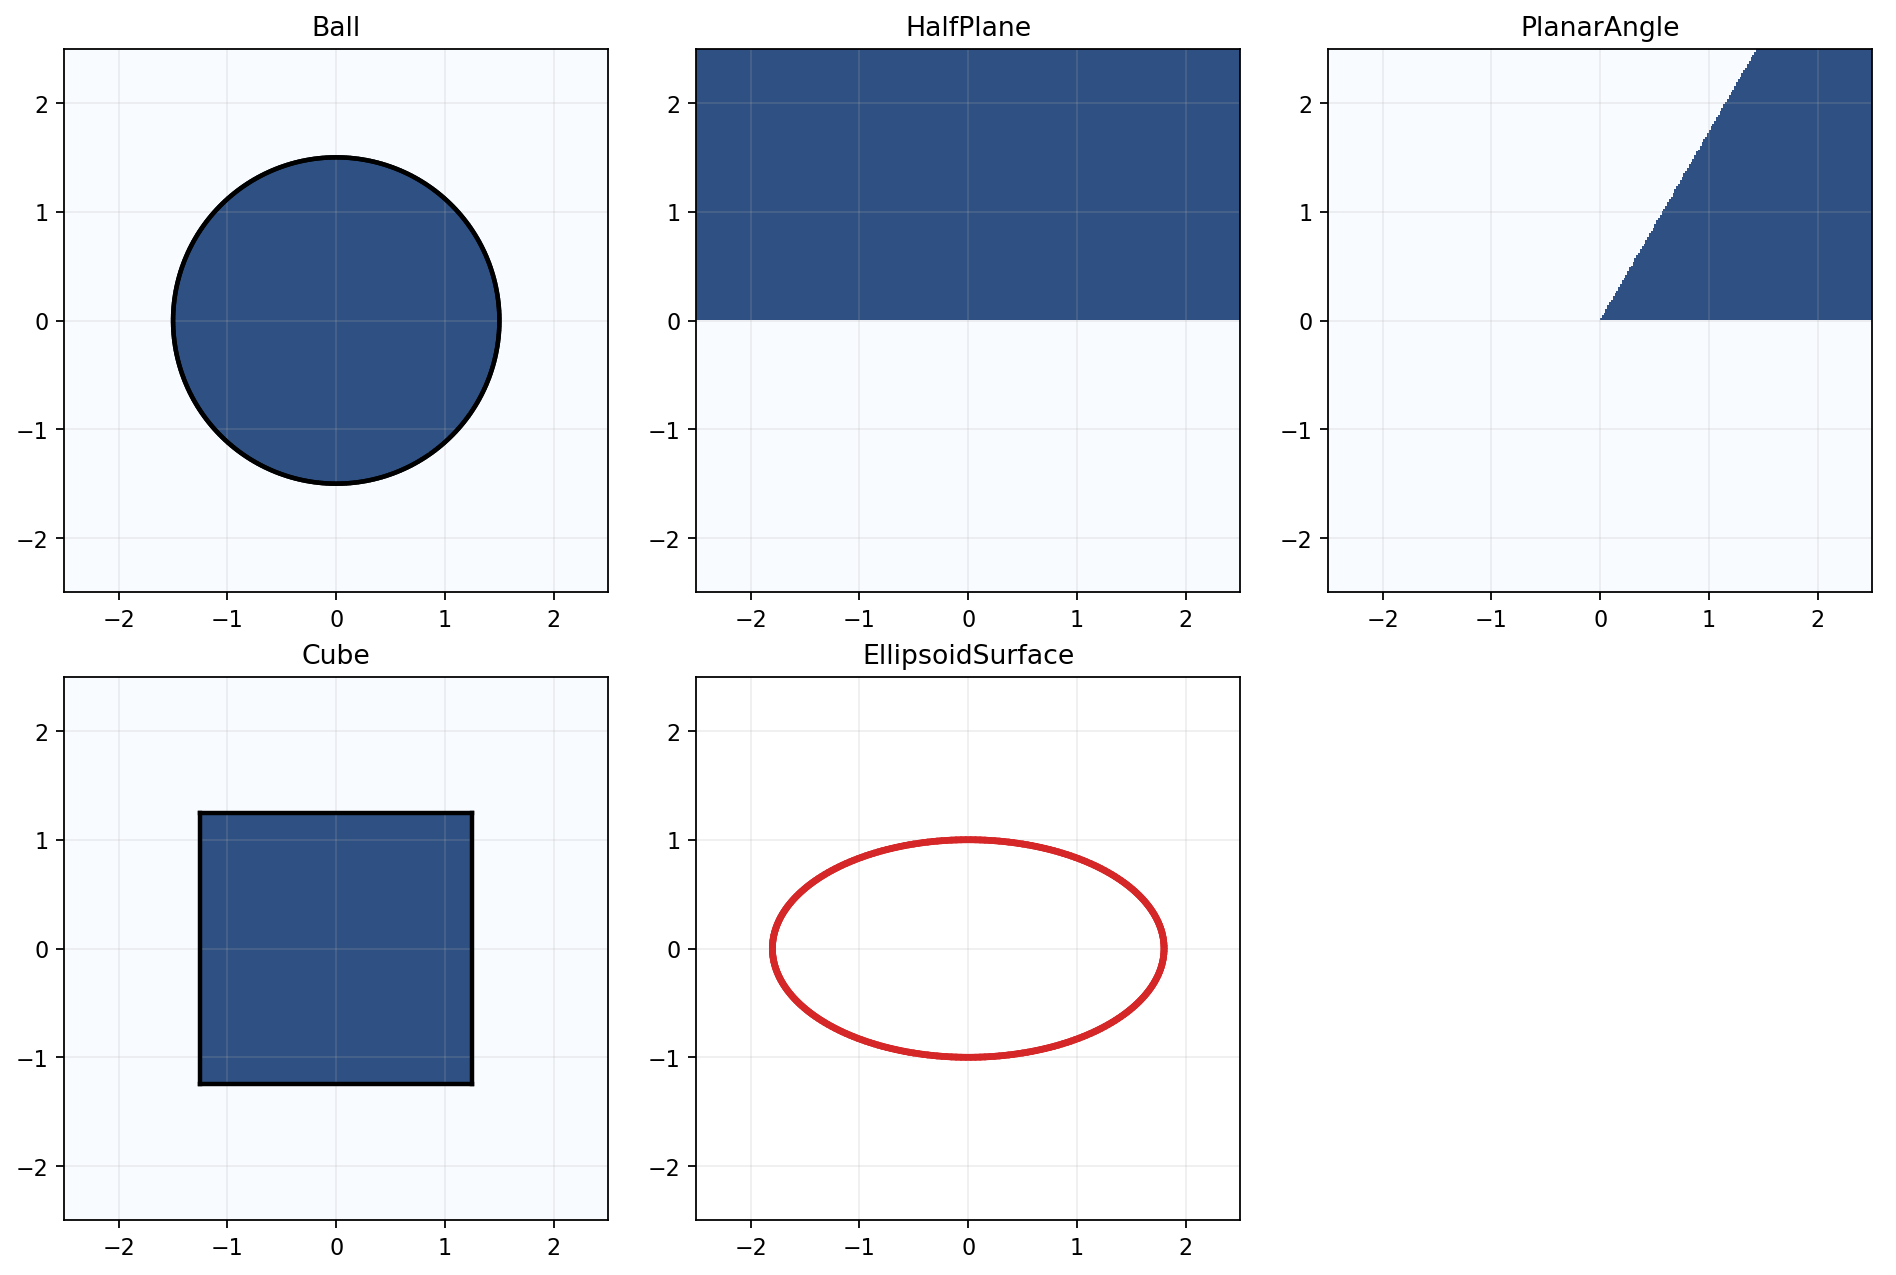

In [3]:
objects = [
    (Ball(FloatPoint(0.0, 0.0), 1.5), 'Ball'),
    (HalfPlane((0.0, 1.0), offset=0.0), 'HalfPlane'),
    (PlanarAngle(FloatPoint(0.0, 0.0), 0.0, math.pi / 3.0), 'PlanarAngle'),
    (Cube(FloatPoint(0.0, 0.0), 1.25), 'Cube'),
    (
        EllipsoidSurface(FloatPoint(0.0, 0.0), ((1.8, 0.0), (0.0, 1.0))),
        'EllipsoidSurface',
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (obj, title) in zip(axes.flat, objects):
    plot_object(ax, obj, title)
axes.flat[-1].axis('off')
fig.tight_layout()